**SERP API DATASET**

**brand_dirty_dataset**

In [1]:
import pandas as pd
df_csv = pd.read_csv('brand_dirty_dataset.csv')


print(f"CSV data loaded successfully. Shape: {df_csv.shape}")
display(df_csv.head())

CSV data loaded successfully. Shape: (1320, 7)


,keyword,title,price,rating,reviews,platform,delivery
0,office chair ergonomic,HP office chair ergonomic Model 603,36225.0,3.7,3241,croma,2 Days
1,microwave oven convection,Samsung microwave oven convection Model 524 !!!,NaN,4.7,1294,amazon,Free Delivery
2,power bank fast charging,Samsung power bank fast charging Model 402,Not Available,NaN,3070,CROMA,Free Delivery
3,microwave oven convection,Dell microwave oven convection Model 877,2507.0,4.7,3446,flipkart,Free Delivery
4,men running shoes,Dell men running shoes Model 536,2176.0,3.8,2031,croma,5 Days


### Initial Data Overview and Missing Value Analysis

In [2]:
# 1. Total number of rows and columns
print(f"Total number of rows: {df_csv.shape[0]}")
print(f"Total number of columns: {df_csv.shape[1]}")

# 2. Data types of each column and check for expected numeric but not numeric
print("\nData types of each column and non-numeric check:")
df_csv.info()

Total number of rows: 1320
Total number of columns: 7

Data types of each column and non-numeric check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   keyword   1320 non-null   object 
 1   title     1320 non-null   object 
 2   price     1194 non-null   object 
 3   rating    1189 non-null   float64
 4   reviews   1320 non-null   object 
 5   platform  1320 non-null   object 
 6   delivery  1320 non-null   object 
dtypes: float64(1), object(6)
memory usage: 72.3+ KB


In [3]:
# 3. Columns with missing values and their percentages
missing_values = df_csv.isnull().sum()
missing_percentage = (df_csv.isnull().sum() / len(df_csv)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

if not missing_info.empty:
    print("\nColumns with missing values and their percentages:")
    display(missing_info)
else:
    print("\nNo missing values found in the dataset.")


Columns with missing values and their percentages:


,Missing Values,Percentage
rating,131,9.924242
price,126,9.545455


**1.PRICE**

In [5]:
import numpy as np
df_csv['price'] = pd.to_numeric(df_csv['price'], errors='coerce')

# Convert invalid prices to NaN
df_csv.loc[df_csv['price'] <= 0, 'price'] = np.nan

# Check missing values
print(df_csv['price'].isna().sum())
print(df_csv['price'].dtype)

218
float64


** Outlier Detection for 'price' column**

Q1 (25th percentile): 12012.25
Q3 (75th percentile): 38817.75
IQR (Interquartile Range): 26805.5
Lower Bound for Outliers: -28196.0
Upper Bound for Outliers: 79026.0

Number of outliers found in 'price' column: 46

Examples of outliers:


355      86400.0
193      87970.0
1018     98570.0
481     103500.0
877     110800.0
701     114690.0
526     123310.0
1285    128720.0
1199    132290.0
970     137250.0
111     146220.0
258     150250.0
1240    171520.0
1217    184400.0
559     189420.0
12      190200.0
119     192440.0
1075    200380.0
1208    220130.0
1124    222300.0
639     229430.0
897     229950.0
960     238330.0
1045    239860.0
890     242370.0
770     265610.0
953     286470.0
985     289730.0
278     317150.0
933     320280.0
1283    323170.0
156     325160.0
506     380730.0
364     383970.0
422     390740.0
735     395720.0
1265    397700.0
1032    402890.0
1015    405890.0
374     436130.0
34      438510.0
282     455330.0
965     461640.0
440     482890.0
1243    489880.0
266     498050.0
Name: price, dtype: float64

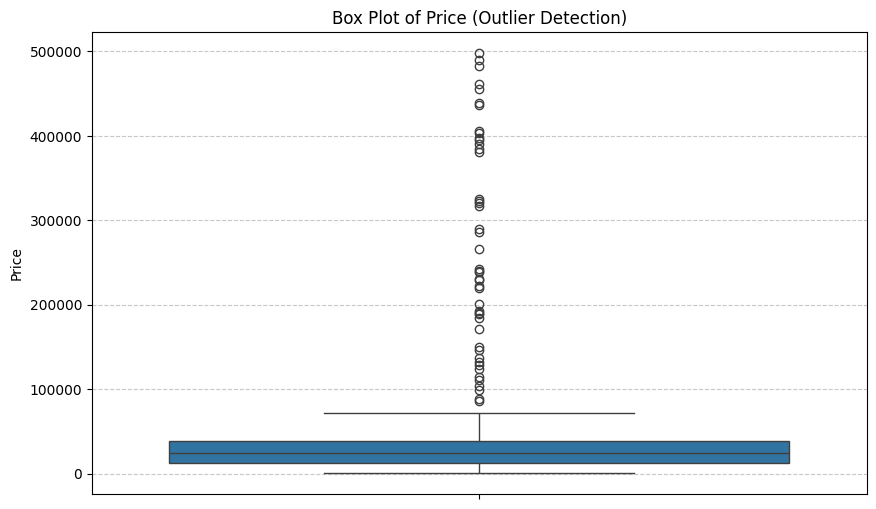

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.nan

df_cs=pd.read_csv('brand_dirty_dataset.csv')

# Convert 'price' column to numeric, coercing errors to NaN
df_cs['price'] = pd.to_numeric(df_cs['price'], errors='coerce')

# Convert invalid prices (<= 0) to NaN, consistent with previous cleaning steps
df_cs.loc[df_cs['price'] <= 0, 'price'] = np.nan

# Calculate Q1, Q3, and IQR for the 'price' column
Q1 = df_cs['price'].quantile(0.25)
Q3 = df_cs['price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_cs['price'][(df_cs['price'] < lower_bound) | (df_cs['price'] > upper_bound)] # Use df_cs for consistency

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")
print(f"\nNumber of outliers found in 'price' column: {len(outliers)}")

# Display some of the outliers
if not outliers.empty:
    print("\nExamples of outliers:")
    display(outliers.sort_values()) # Changed .sort() to .sort_values()
else:
    print("\nNo outliers found based on IQR method.")

# Visualize outliers using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_cs['price']) # Use df_cs for consistency
plt.title('Box Plot of Price (Outlier Detection)')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
outlier_data = df_csv.loc[outliers.index, ['keyword', 'title', 'price']]
print(outlier_data.sort_values(['keyword', 'price'], ascending=[True, False]))

                        keyword  \
1243            air fryer India   
278             air fryer India   
953             air fryer India   
890             air fryer India   
1124            air fryer India   
1217            air fryer India   
970             air fryer India   
481             air fryer India   
266           men running shoes   
965           men running shoes   
422           men running shoes   
506           men running shoes   
933           men running shoes   
111           men running shoes   
440   microwave oven convection   
34    microwave oven convection   
1032  microwave oven convection   
364   microwave oven convection   
156   microwave oven convection   
1283  microwave oven convection   
770   microwave oven convection   
897   microwave oven convection   
1208  microwave oven convection   
119   microwave oven convection   
559   microwave oven convection   
258   microwave oven convection   
1285  microwave oven convection   
877   microwave oven

In [ ]:
# q96 = df_csv['price'].quantile(0.96)

# df_csv['price'] = df_csv['price'].clip(upper=q96)
# print(df_csv['price'])
# df_csv.iloc[1243]

0       36225.0
1           NaN
2           NaN
3        2507.0
4        2176.0
         ...   
1315    20097.0
1316    33684.0
1317    38959.0
1318        NaN
1319        NaN
Name: price, Length: 1320, dtype: float64


,1243
keyword,air fryer India
title,Nike air fryer India Model 162 !!!
price,87907.2
rating,4.1
reviews,4559
platform,flipkart
delivery,5 Days


In [9]:
df_csv.groupby(['keyword','platform','delivery'])['price'].median()

keyword                   platform          delivery     
air fryer India           AMAZON            2 Days           31084.0
                                            5 Days           32579.0
                                            Free Delivery    28104.5
                          CROMA             2 Days           13788.0
                                            5 Days           19982.0
                                                              ...   
power bank fast charging  flipkart          5 Days           26131.0
                                            Free Delivery    35395.0
                          reliance digital  2 Days           29596.0
                                            5 Days           34266.5
                                            Free Delivery    32170.0
Name: price, Length: 120, dtype: float64

In [10]:
df_csv['price'] = (
    df_csv.groupby(['keyword','platform','delivery'])['price']
          .transform(lambda x: x.fillna(x.median()))
)

print(f"Missing values in 'price' after imputation: {df_csv['price'].isnull().sum()}")
print(df_csv['price'].dtype)

Missing values in 'price' after imputation: 0
float64


Right-skewed (positively skewed)

Concentrated at lower and moderate prices

Contains a few extremely large values

In [11]:
df_csv['price'].skew()


6.014400353657895

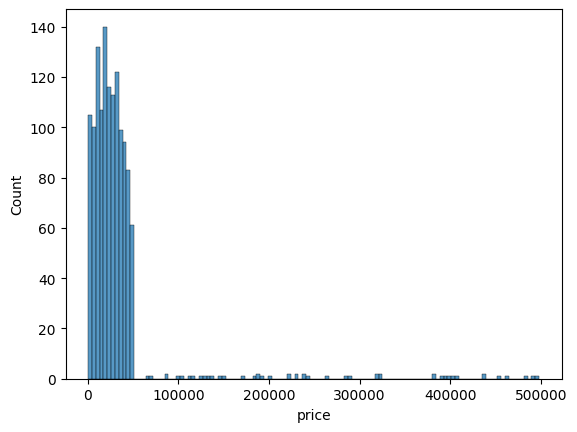

In [12]:
sns.histplot(df_csv['price'])
plt.show()

In [13]:
print(df_csv['price'].isna().sum())
print(df_csv['price'].dtype)

0
float64


**2.RATING**

### Detailed Cleaning for the 'rating' column

In [14]:
missing_ratings_after_range_check = df_cs['rating'].isnull().sum()
print(missing_ratings_after_range_check)
df_csv['rating'].dtype

131


dtype('float64')

In [15]:
# 1. Check for and handle out-of-range values (assuming ratings are 1-5)
# Convert ratings outside 1-5 range to NaN
initial_invalid_ratings = df_csv['rating'][(df_csv['rating'] < 1) | (df_csv['rating'] > 5)].count()
print(initial_invalid_ratings)

0


In [16]:
df_csv.groupby(['keyword','platform','delivery'])['rating'].mean()

keyword                   platform          delivery     
air fryer India           AMAZON            2 Days           3.640000
                                            5 Days           3.925000
                                            Free Delivery    3.400000
                          CROMA             2 Days           3.654545
                                            5 Days           3.868750
                                                               ...   
power bank fast charging  flipkart          5 Days           3.657143
                                            Free Delivery    3.671429
                          reliance digital  2 Days           4.077778
                                            5 Days           3.650000
                                            Free Delivery    3.900000
Name: rating, Length: 120, dtype: float64

### Imputing Missing 'rating' Values with Total Mean

In [17]:
# Calculate the overall mean of the 'rating' column
total_mean_rating = df_csv['rating'].mean()

# Impute any remaining missing 'rating' values with the total mean
df_csv['rating'] = (
    df_csv.groupby(['keyword','platform','delivery'])['rating']
          .transform(lambda x: x.fillna(x.mean())).round(1)
)

print(f"Overall mean rating used for imputation: {total_mean_rating:.2f}")
print(f"Missing values in 'rating' after total mean imputation: {df_csv['rating'].isnull().sum()}")
print(f"'rating' column data type: {df_csv['rating'].dtype}")

# Display basic statistics for the 'rating' column after imputation
print("\nStatistics for 'rating' column after total mean imputation:")
print(df_csv['rating'].describe())

# As ratings are typically floats (e.g., 3.5, 4.2), we'll keep it as float64 after imputation.
# If the user later requires integer representation, explicit rounding and conversion can be done.

Overall mean rating used for imputation: 3.79
Missing values in 'rating' after total mean imputation: 0
'rating' column data type: float64

Statistics for 'rating' column after total mean imputation:
count    1320.000000
mean        3.790985
std         0.679206
min         2.500000
25%         3.300000
50%         3.800000
75%         4.400000
max         5.000000
Name: rating, dtype: float64


### Reviewing 'rating' Distribution After Mean Imputation

In [19]:
print(df_csv['rating'].skew())

-0.08619060814495878


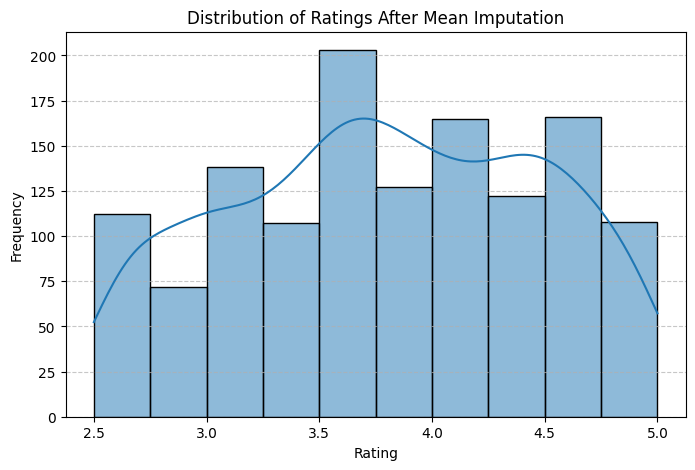

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize 'rating' distribution with a histogram after mean imputation
plt.figure(figsize=(8, 5))
sns.histplot(df_csv['rating'], kde=True, bins=10) # More bins for float values
plt.title('Distribution of Ratings After Mean Imputation')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
missing_ratings_after_range_check = df_csv['rating'].isnull().sum()
print(missing_ratings_after_range_check)

0


**3.Reviews**

The `reviews` column is currently of `object` type, and its `value_counts` suggest it contains string representations of numbers, and potentially some non-numeric characters (like 'k' for thousands). I will convert it to a numeric type, coercing errors to `NaN`, and then impute these `NaN` values with the median.

In [22]:
def clean_reviews(reviews_series):
    cleaned_series = (
        reviews_series.astype(str)
        .str.lower()
        .str.replace(r'[^\d]', '', regex=True)
    )

    numeric_series = pd.to_numeric(
        cleaned_series,
        errors='coerce'
    )

    return numeric_series


# Clean reviews
df_csv['reviews'] = clean_reviews(df_csv['reviews'])


# Group-wise smart imputation
def smart_impute(group):

    q1 = group['reviews'].quantile(0.25)
    q3 = group['reviews'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers_exist = (
        ((group['reviews'] < lower) |
         (group['reviews'] > upper))
        .sum() > 0
    )

    if outliers_exist:
        fill_value = group['reviews'].median()
        method = "Median"
    else:
        fill_value = group['reviews'].mean()
        method = "Mean"

    missing_count = group['reviews'].isna().sum()

    if missing_count > 0:
        print(
            f"Group: keyword={group.name[0]}, "
            f"platform={group.name[1]}, "
            f"delivery={group.name[2]}"
        )
        print(f"Missing values: {missing_count}")
        print(f"Imputation method: {method}")
        print(f"Imputation value: {fill_value}")
        print("-" * 50)

    group['reviews'] = group['reviews'].fillna(fill_value)

    return group

df_csv = (
    df_csv
    .groupby(
        ['keyword', 'platform', 'delivery'],
        group_keys=False
    )
    .apply(smart_impute)
)

# Remaining missing values (if any)
# df_csv['reviews'] = (
#     df_csv['reviews']
#     .fillna(df_csv['reviews'].median())
# )

# Convert to integer
df_csv['reviews'] = df_csv['reviews'].round().astype('Int64')

print("Missing values:", df_csv['reviews'].isnull().sum())
print(df_csv['reviews'].dtype)

display(df_csv['reviews'].describe())

Group: keyword=air fryer India, platform=CROMA, delivery=2 Days
Missing values: 1
Imputation method: Mean
Imputation value: 1538.3
--------------------------------------------------
Group: keyword=air fryer India, platform=RELIANCE DIGITAL, delivery=2 Days
Missing values: 1
Imputation method: Mean
Imputation value: 2325.4
--------------------------------------------------
Group: keyword=air fryer India, platform=RELIANCE DIGITAL, delivery=5 Days
Missing values: 1
Imputation method: Median
Imputation value: 2792.5
--------------------------------------------------
Group: keyword=air fryer India, platform=amazon, delivery=2 Days
Missing values: 1
Imputation method: Mean
Imputation value: 2245.4545454545455
--------------------------------------------------
Group: keyword=air fryer India, platform=croma, delivery=2 Days
Missing values: 1
Imputation method: Mean
Imputation value: 1783.1666666666667
--------------------------------------------------
Group: keyword=air fryer India, platform=

count         1320.0
mean     2419.893939
std      1419.401534
min             14.0
25%           1151.0
50%           2334.5
75%           3611.0
max           4997.0
Name: reviews, dtype: Float64

### 4.Standardizing Categorical Values: 'platform' and 'delivery'

In [23]:
# =========================
# PLATFORM CLEANING
# =========================

print("Original 'platform' unique values:")
display(df_csv['platform'].unique())

df_csv['platform'] = (
    df_csv['platform']
    .astype(str)
    .str.lower()
    .str.strip()
)

# Common platform mappings (add more if needed)
platform_mapping = {
    'amazon.in': 'amazon',
    'amazon india': 'amazon',
    'flipkart.com': 'flipkart',
    'fk': 'flipkart'
}

df_csv['platform'] = df_csv['platform'].replace(platform_mapping)

print("\nStandardized 'platform' unique values:")
display(df_csv['platform'].unique())


# =========================
# DELIVERY CLEANING
# =========================

print("\nOriginal 'delivery' unique values:")
display(df_csv['delivery'].unique())

df_csv['delivery'] = (
    df_csv['delivery']
    .astype(str)
    .str.lower()
    .str.strip()
)

# Standardize common delivery variations
delivery_mapping = {

    # Free delivery variants
    'free shipping': 'free delivery',
    'free ship': 'free delivery',
    'free-delivery': 'free delivery',
    'free': 'free delivery',

    # Same-day variants
    'same day': 'same-day',
    'same-day delivery': 'same-day',

    # Not available variants
    'na': 'not available',
    'n/a': 'not available',
    'not applicable': 'not available',
    'unavailable': 'not available',

    # Days variants
    '2day': '2 days',
    '2days': '2 days',
    '5day': '5 days',
    '5days': '5 days'
}

df_csv['delivery'] = df_csv['delivery'].replace(delivery_mapping)

print("\nStandardized 'delivery' unique values:")
display(df_csv['delivery'].unique())


# =========================
# FREQUENCY CHECK
# =========================

print("\nPlatform Counts:")
display(df_csv['platform'].value_counts())

print("\nDelivery Counts:")
display(df_csv['delivery'].value_counts())

Original 'platform' unique values:


array(['croma', 'amazon', 'CROMA', 'flipkart', 'RELIANCE DIGITAL',
       'AMAZON', 'reliance digital', 'FLIPKART'], dtype=object)


Standardized 'platform' unique values:


array(['croma', 'amazon', 'flipkart', 'reliance digital'], dtype=object)


Original 'delivery' unique values:


...

array(['2 days', 'free delivery', '5 days'], dtype=object)


Platform Counts:


platform
reliance digital    353
amazon              337
croma               326
flipkart            304
Name: count, dtype: int64


Delivery Counts:


delivery
free delivery    463
2 days           435
5 days           422
Name: count, dtype: int64

**5.Title**

**Noise removal from title column**

In [24]:
df_csv['title'].str.contains('!', regex=False, na=False).value_counts()

title
False    1184
True      136
Name: count, dtype: int64

In [25]:
df_csv['title'] = (
    df_csv['title']
    .str.replace(r'[!]+', '', regex=True)
    .str.strip()
)

In [26]:
df_csv['title'].str.contains('!', regex=False, na=False).value_counts()

title
False    1320
Name: count, dtype: int64

**ENTIRE DATASET DUPLICATES**
### Checking for Duplicate Rows in the Entire Dataset

In [27]:
# Identify duplicate rows across all columns
duplicate_rows_df = df_csv[df_csv.duplicated(keep=False)]

print(f"Number of duplicate rows found in the dataset: {len(duplicate_rows_df)}")

if not duplicate_rows_df.empty:
    print("\nHere are the duplicate rows (showing all occurrences):")
    display(duplicate_rows_df.sort_values(by=list(df_csv.columns)))
else:
    print("No duplicate rows found in the dataset.")

Number of duplicate rows found in the dataset: 150

Here are the duplicate rows (showing all occurrences):


,keyword,title,price,rating,reviews,platform,delivery
1067,air fryer India,Boat air fryer India Model 433,30954.0,4.2,746,amazon,5 days
1291,air fryer India,Boat air fryer India Model 433,30954.0,4.2,746,amazon,5 days
497,air fryer India,Boat air fryer India Model 608,10828.0,3.3,4277,flipkart,5 days
1205,air fryer India,Boat air fryer India Model 608,10828.0,3.3,4277,flipkart,5 days
562,air fryer India,Boat air fryer India Model 698,46221.0,3.6,1104,reliance digital,2 days
...,...,...,...,...,...,...,...
1271,power bank fast charging,Samsung power bank fast charging Model 596,26397.0,3.3,1033,reliance digital,free delivery
365,power bank fast charging,Sony power bank fast charging Model 509,38591.0,2.7,969,reliance digital,5 days
1289,power bank fast charging,Sony power bank fast charging Model 509,38591.0,2.7,969,reliance digital,5 days
382,power bank fast charging,Sony power bank fast charging Model 747,29596.0,4.3,934,reliance digital,2 days


In [28]:
print("Removing duplicate rows...")
initial_rows = df_csv.shape[0]
df_csv.drop_duplicates(inplace=True)
final_rows = df_csv.shape[0]
print(f"Number of rows before removing duplicates: {initial_rows}")
print(f"Number of rows after removing duplicates: {final_rows}")
print(f"Number of duplicates removed: {initial_rows - final_rows}")

Removing duplicate rows...
Number of rows before removing duplicates: 1320
Number of rows after removing duplicates: 1245
Number of duplicates removed: 75


In [29]:
print("Original 'reviews' column info:")
df_csv['reviews'].info()
print("\nOriginal 'reviews' unique values (first 20 if many):")
display(df_csv['reviews'].value_counts().head(20))

Original 'reviews' column info:
<class 'pandas.core.series.Series'>
Index: 1245 entries, 0 to 1319
Series name: reviews
Non-Null Count  Dtype
--------------  -----
1245 non-null   Int64
dtypes: Int64(1)
memory usage: 20.7 KB

Original 'reviews' unique values (first 20 if many):


reviews
629     4
4794    3
4979    3
2655    3
1104    3
4643    3
4559    3
3938    3
461     3
2729    3
660     3
1783    3
3085    3
2426    3
1871    3
418     3
2261    3
1093    3
4526    2
465     2
Name: count, dtype: Int64

**Standardize column names**

In [30]:
# Standardize column names
df_csv.columns = (
    df_csv.columns
    .str.strip()                # Remove leading/trailing spaces
    .str.lower()                # Convert to lowercase
    .str.replace(' ', '_')      # Replace spaces with underscores
    .str.replace(r'[^\w]', '', regex=True)  # Remove special characters
)

print(df_csv.columns)

Index(['keyword', 'title', 'price', 'rating', 'reviews', 'platform',
       'delivery'],
      dtype='object')


In [31]:
print(df_csv)

                        keyword                                        title  \
0        office chair ergonomic          HP office chair ergonomic Model 603   
1     microwave oven convection  Samsung microwave oven convection Model 524   
2      power bank fast charging   Samsung power bank fast charging Model 402   
3     microwave oven convection     Dell microwave oven convection Model 877   
4             men running shoes             Dell men running shoes Model 536   
...                         ...                                          ...   
1309     office chair ergonomic          LG office chair ergonomic Model 829   
1310  microwave oven convection     Boat microwave oven convection Model 727   
1311            air fryer India                 LG air fryer India Model 363   
1314  microwave oven convection  Samsung microwave oven convection Model 524   
1319  microwave oven convection  Philips microwave oven convection Model 322   

        price  rating  reviews  platfor

In [32]:
df_csv.duplicated().sum()

0

In [33]:
# Dataset shape
print("Dataset Shape:", df_csv.shape)

# Data types
print("\nData Types:")
print(df_csv.dtypes)

# Missing values
print("\nMissing Values:")
print(df_csv.isnull().sum())

# Missing percentages
print("\nMissing Percentage:")
print((df_csv.isnull().mean() * 100).round(2))

# Check numeric columns
print("\nNumeric Column Types:")
for col in ['price', 'rating', 'reviews']:
    print(f"{col}: {df_csv[col].dtype}")

Dataset Shape: (1245, 7)

Data Types:
keyword      object
title        object
price       float64
rating      float64
reviews       Int64
platform     object
delivery     object
dtype: object

Missing Values:
keyword     0
title       0
price       0
rating      0
reviews     0
platform    0
delivery    0
dtype: int64

Missing Percentage:
keyword     0.0
title       0.0
price       0.0
rating      0.0
reviews     0.0
platform    0.0
delivery    0.0
dtype: float64

Numeric Column Types:
price: float64
rating: float64
reviews: Int64


 **price
rating
reviews(many_reviews_flag)**

price
rating
reviews(many_reviews_flag)
many_reviews flag (row for model understanding or for any analysis)

reviews	  many_reviews_flag
120	          0
450	          0
many	      1
320	          0
many	      1

In [ ]:
df_csv['delivery'].isnull().sum()

np.int64(0)

Duplicates based on group by

In [34]:
# Find duplicate products based on keyword + title + platform + rating + reviews
dup_all = df_csv[df_csv.duplicated(subset=['keyword', 'title', 'platform', 'rating' , 'reviews'], keep=False)]

print(f"Number of duplicate rows: {len(dup_all)}")
display(dup_all.sort_values(['keyword', 'title', 'platform' , 'rating' , 'reviews']))
#32317  vs 323170
#12872  vs 128720
#4773   vs 47730
#23833  vs 238330
#9857   vs 98570
#11469  vs 114690
#/** These look more like:

# Data entry errors
# Scraping errors
# Price scaling issues

# rather than genuine duplicate products.**/

Number of duplicate rows: 58


,keyword,title,price,rating,reviews,platform,delivery
1090,air fryer India,Dell air fryer India Model 243,18440.0,2.6,3171,amazon,free delivery
1217,air fryer India,Dell air fryer India Model 243,184400.0,2.6,3171,amazon,free delivery
602,air fryer India,Dell air fryer India Model 363,23530.0,4.0,641,flipkart,2 days
1210,air fryer India,Dell air fryer India Model 363,22353.0,4.0,641,flipkart,2 days
1119,air fryer India,Nike air fryer India Model 162,48988.0,4.1,4559,flipkart,5 days
1243,air fryer India,Nike air fryer India Model 162,489880.0,4.1,4559,flipkart,5 days
971,air fryer India,Philips air fryer India Model 213,21190.0,4.4,2655,amazon,2 days
1266,air fryer India,Philips air fryer India Model 213,31084.0,4.4,2655,amazon,2 days
601,men running shoes,HP men running shoes Model 129,42006.0,4.5,3287,flipkart,5 days
1245,men running shoes,HP men running shoes Model 129,29804.5,4.5,3287,flipkart,5 days


In [ ]:
#RATIO OF 10 -18
dup_all['price_ratio'] = (
    dup_all.groupby(
        ['keyword', 'title', 'platform', 'rating', 'reviews']
    )['price']
    .transform(lambda x: x.max() / x.min())
)

print(dup_all['price_ratio'].value_counts())

Series([], Name: count, dtype: int64)


DROP THOSE ROWS

In [36]:
df_csv = (
    df_csv.sort_values('price')
          .drop_duplicates(
              subset=[
                  'keyword',
                  'title',
                  'platform',
                  'rating',
                  'reviews'
              ],
              keep='first'
          )
)

In [37]:
# Find duplicate products based on keyword + title + platform + rating + reviews
dup_all = df_csv[df_csv.duplicated(subset=['keyword', 'title', 'platform', 'rating' , 'reviews'], keep=False)]

print(f"Number of duplicate rows: {len(dup_all)}")
display(dup_all.sort_values(['keyword', 'title', 'platform' , 'rating' , 'reviews']))

Number of duplicate rows: 0


,keyword,title,price,rating,reviews,platform,delivery


GROUP BY CHECKING BUT NOT REMOVED AS NOT NECESSARY 

In [41]:
# Find duplicate products based on keyword + title
dup_kw_title = df_csv[df_csv.duplicated(subset=['keyword', 'title','platform','price','rating'], keep=False)]

print(f"Number of duplicate rows: {len(dup_kw_title)}")
display(dup_kw_title.sort_values(['keyword', 'title','platform','price','rating']))

Number of duplicate rows: 12


,keyword,title,price,rating,reviews,platform,delivery
597,air fryer India,HP air fryer India Model 947,26570.0,4.9,1076,croma,2 days
1229,air fryer India,HP air fryer India Model 947,26570.0,4.9,1783,croma,2 days
996,air fryer India,LG air fryer India Model 363,10393.0,3.5,3600,croma,2 days
1311,air fryer India,LG air fryer India Model 363,10393.0,3.5,1538,croma,2 days
180,air fryer India,Philips air fryer India Model 269,22083.0,3.6,1770,flipkart,5 days
1213,air fryer India,Philips air fryer India Model 269,22083.0,3.6,3111,flipkart,5 days
977,office chair ergonomic,LG office chair ergonomic Model 829,48662.0,4.2,771,amazon,2 days
1309,office chair ergonomic,LG office chair ergonomic Model 829,48662.0,4.2,1943,amazon,2 days
1287,office chair ergonomic,Philips office chair ergonomic Model 414,12081.0,3.2,2235,amazon,free delivery
808,office chair ergonomic,Philips office chair ergonomic Model 414,12081.0,3.2,1965,amazon,free delivery


In [ ]:
# Find duplicate products based on title + platform
dup_title_platform = df_csv[df_csv.duplicated(subset=['title', 'platform'], keep=False)]

print(f"Number of duplicate rows: {len(dup_title_platform)}")
display(dup_title_platform.sort_values(['title', 'platform']))

Number of duplicate rows: 66


,keyword,title,price,rating,reviews,platform,delivery
111,men running shoes,Boat men running shoes Model 401,146220.0,3.2,1261,reliance digital,5 days
851,men running shoes,Boat men running shoes Model 401,22398.0,4.4,3883,reliance digital,free delivery
946,microwave oven convection,Boat microwave oven convection Model 156,22013.0,4.8,4758,croma,2 days
1208,microwave oven convection,Boat microwave oven convection Model 156,220130.0,4.8,4501,croma,2 days
547,microwave oven convection,Boat microwave oven convection Model 458,24180.5,3.1,1093,amazon,5 days
...,...,...,...,...,...,...,...
1279,men running shoes,Sony men running shoes Model 584,22398.0,4.1,4758,croma,5 days
694,microwave oven convection,Sony microwave oven convection Model 852,4773.0,4.5,3005,croma,2 days
1238,microwave oven convection,Sony microwave oven convection Model 852,47730.0,4.5,3005,croma,2 days
1021,power bank fast charging,Sony power bank fast charging Model 327,24058.0,4.6,251,croma,5 days


keyword   = air fryer India

title     = Dell air fryer India Model 243

platform  = amazon

rating    = 2.6

reviews   = 3171

price = 18440 |
price = 184400

In [42]:
df_csv.shape

(1216, 7)

In [43]:
df_csv['price'].isnull().sum()

0

In [46]:
df_csv[['price','rating','reviews']].dtypes

price      float64
rating     float64
reviews      Int64
dtype: object

In [47]:
# Save the cleaned DataFrame to a new CSV file
df_csv.to_csv('cleaned_brand_data.csv', index=False)
print("Cleaned data saved to 'cleaned_brand_data.csv'")

Cleaned data saved to 'cleaned_brand_data.csv'


**Remove ratings or reviews only if**

You are specifically analyzing:


1 Customer sentiment

2 Product popularity

3 Rating prediction

**Unusual brand related category items**

Brand    ||    Product Category


Nike     ||       Air Fryer

Dell      ||    Running Shoes

HP          ||   Microwave Oven